# SILVA Operator Options

The reference graph model keeps the Figure 1 decomposition explicit:

$$
z_{k+1}
=
(1-\alpha)z_k
+
\alpha\Phi\{S_\theta(x)+L_\theta(\tanh z_k,E)+G_\theta(\tanh z_k,b)\}.
$$

`hidden_dim`, `stack_alphas`, `graph_mode`, `attention_mode`, solver settings,
and readout dimensions are constructor arguments.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[15]](https://jseluis.github.io/silva-networks/paper/references/#ref-15), [[16]](https://jseluis.github.io/silva-networks/paper/references/#ref-16), [[17]](https://jseluis.github.io/silva-networks/paper/references/#ref-17), [[18]](https://jseluis.github.io/silva-networks/paper/references/#ref-18), [[19]](https://jseluis.github.io/silva-networks/paper/references/#ref-19), [[20]](https://jseluis.github.io/silva-networks/paper/references/#ref-20), [[29]](https://jseluis.github.io/silva-networks/paper/references/#ref-29). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
from silva_networks import (
    SILVAGraphPresetNetwork,
    SILVAMolecularRegressor,
    SILVAVisionVectorClassifier,
    SolverConfig,
    damped_spectral_radius,
    molecular_to_silva_graph,
    tabular_to_silva_graph,
)

torch.manual_seed(6)
x = torch.randn(9, 5)
y = (x[:, 0] > 0).long()
edge_index = torch.tensor(
    [[0, 1, 2, 3, 4, 5, 6, 7, 8],
     [1, 2, 3, 4, 5, 6, 7, 8, 0]],
    dtype=torch.long,
)

The SILVA ablations are available through operator names. Each row below
uses the same input graph and changes only the local or global interaction.
The ablation value is the string `"none"`: it removes that branch from
$L_\theta$ or $G_\theta$. Solver self-persistence
$(1-\alpha)z_k$ is still present, so the no-local/no-global case is
stimulus plus damped recurrent persistence.

In [3]:
cases = [
    ("full", "GAT", "simple"),
    ("local_only", "GAT", "none"),
    ("global_only", "none", "simple"),
    ("static_global", "GAT", "static"),
    ("topk_global", "GAT", "topk"),
]

case_rows = []
for name, graph_mode, attention_mode in cases:
    model = SILVAGraphPresetNetwork(
        in_dim=5,
        hidden_dim=[12, 8],
        out_dim=2,
        task="node",
        graph_mode=graph_mode,
        attention_mode=attention_mode,
        num_heads=2,
        k_neighbors=3,
        stack_alphas=[0.5, 0.2],
        max_iter=3,
    )
    result = model(x, edge_index=edge_index, return_results=True)
    residuals = [float(r.residual) for r in result.solver_results]
    case_rows.append({"case": name, "shape": tuple(result.output.shape), "residuals": residuals})
    print(name, tuple(result.output.shape), [round(value, 5) for value in residuals])
case_rows

full (9, 2) [5.69209, 5.83524]
local_only (9, 2) [4.29137, 5.87878]
global_only (9, 2) [2.68777, 5.45418]
static_global (9, 2) [4.39082, 6.33538]
topk_global (9, 2) [6.57354, 6.09027]


[{'case': 'full',
  'shape': (9, 2),
  'residuals': [5.692088603973389, 5.835236072540283]},
 {'case': 'local_only',
  'shape': (9, 2),
  'residuals': [4.2913689613342285, 5.878783702850342]},
 {'case': 'global_only',
  'shape': (9, 2),
  'residuals': [2.6877706050872803, 5.454184055328369]},
 {'case': 'static_global',
  'shape': (9, 2),
  'residuals': [4.390822887420654, 6.335383892059326]},
 {'case': 'topk_global',
  'shape': (9, 2),
  'residuals': [6.573538780212402, 6.090270519256592]}]

The bar plot compares the largest final residual across the ablation stack.
It is a quick numerical check that changing an operator still produces a
finite solved state on the same input.

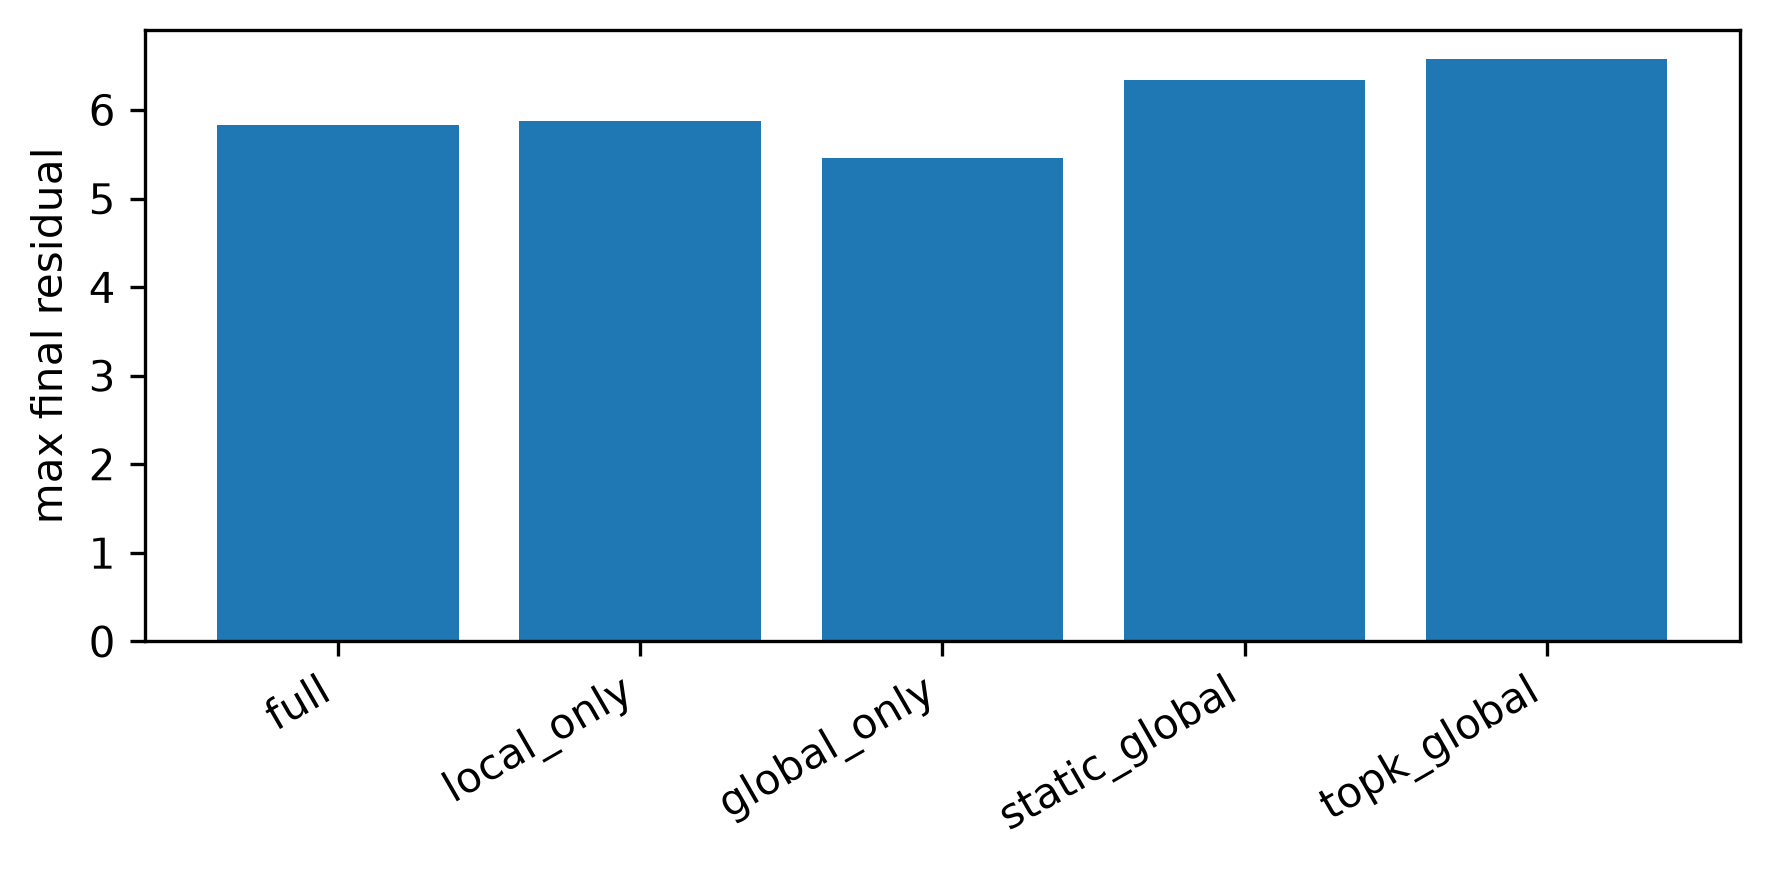

In [4]:
plt.figure(figsize=(6, 3))
plt.bar([row["case"] for row in case_rows], [max(row["residuals"]) for row in case_rows])
plt.xticks(rotation=30, ha="right")
plt.ylabel("max final residual")
plt.tight_layout()

The generic API accepts per-layer solvers and custom branches. A custom branch
only has to return a tensor shaped like the recurrent state.

In [5]:
class BiasLocal(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.zeros(dim))

    def forward(self, z, edge_index=None, edge_attr=None, batch=None):
        return torch.tanh(z + self.bias)

from silva_networks import SILVAGraphNetwork

custom = SILVAGraphNetwork(
    in_dim=5,
    hidden_dims=[12, 8, 8],
    out_dim=2,
    task="node",
    local=lambda dim, index: BiasLocal(dim),
    global_term=["mean", "simple", "topk_attention"],
    global_kwargs=[None, None, {"k": 4}],
    self_term=[None, "linear", None],
    config=[
        SolverConfig(solver="picard", max_iter=3, alpha=0.5),
        SolverConfig(solver="anderson", max_iter=3, alpha=0.35, history=3),
        SolverConfig(solver="broyden", max_iter=3, alpha=0.25),
    ],
)
custom(x, edge_index=edge_index).shape

torch.Size([9, 2])

Molecular SILVA accepts categorical atom/bond ids or continuous feature
vectors. The continuous path uses explicit input projectors.

In [6]:
mol = molecular_to_silva_graph(
    x=torch.randn(5, 3),
    edge_index=torch.tensor([[0, 1, 2, 3, 4, 1], [1, 2, 0, 4, 3, 0]]),
    edge_attr=torch.randn(6, 2),
    batch=torch.tensor([0, 0, 0, 1, 1]),
    y=torch.tensor([0.3, -0.1]),
)
molecular_model = SILVAMolecularRegressor(
    hidden_dim=[9, 6],
    atom_feature_dim=3,
    bond_feature_dim=2,
    num_heads=3,
    alphas=(0.5, 0.2),
    max_iter=2,
    dropout=0.0,
    spectral_norm=False,
)
molecular_model(**mol.model_kwargs(), return_results=True).output

tensor([-0.1630, -0.0136], grad_fn=<SqueezeBackward1>)

Lyapunov-style and Jacobian diagnostics can be run on any transition. Here the
spectral-radius estimate is applied to the first SILVA layer transition.

In [7]:
layer = SILVAGraphPresetNetwork(
    in_dim=5,
    hidden_dim=8,
    out_dim=2,
    stack_alphas=[0.5],
    num_heads=2,
    max_iter=3,
).layers[0]
z0 = torch.zeros(x.shape[0], 8)
z_star = layer(x, edge_index=edge_index)
rho = damped_spectral_radius(lambda z: layer.f(z, x, edge_index=edge_index), z_star, alpha=0.5, iters=3)
rho

0.755165159702301

## Citation and Sources

If this notebook or package is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.2.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work is connected to the SILVA Networks paper, cite the paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background references used in the tutorial suite include:

- Deep Equilibrium Models, Bai, Kolter, and Koltun, NeurIPS 2019:
  https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models, Bai, Koltun, and Kolter, NeurIPS 2020:
  https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization, Bai, Koltun, and
  Kolter, ICML 2021: https://arxiv.org/abs/2106.14342
- Graph Attention Networks, Velickovic et al., ICLR 2018:
  https://arxiv.org/abs/1710.10903
- Attention Is All You Need, Vaswani et al., 2017:
  https://arxiv.org/abs/1706.03762

## From 06 Silva Operator Options to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [8]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [9]:
notebook_reproduction_record = {
    "notebook": '06_silva_operator_options.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '06_silva_operator_options.ipynb',
 'state': 'the tensor solved to equilibrium',
 'condition': 'the observed input or source tensor',
 'transition': 'the state-preserving transition evaluated by the root solver',
 'invariants': 'shape, device, dtype, finiteness, and differentiability',
 'compact_metric': 'fixed-point residual and task error against a deterministic target',
 'scale_axis': 'state width, batch size, and data volume'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **operator feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the tensor solved to equilibrium**, and its repeated map,
**the state-preserving transition evaluated by the root solver**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [10]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('operator feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


operator feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


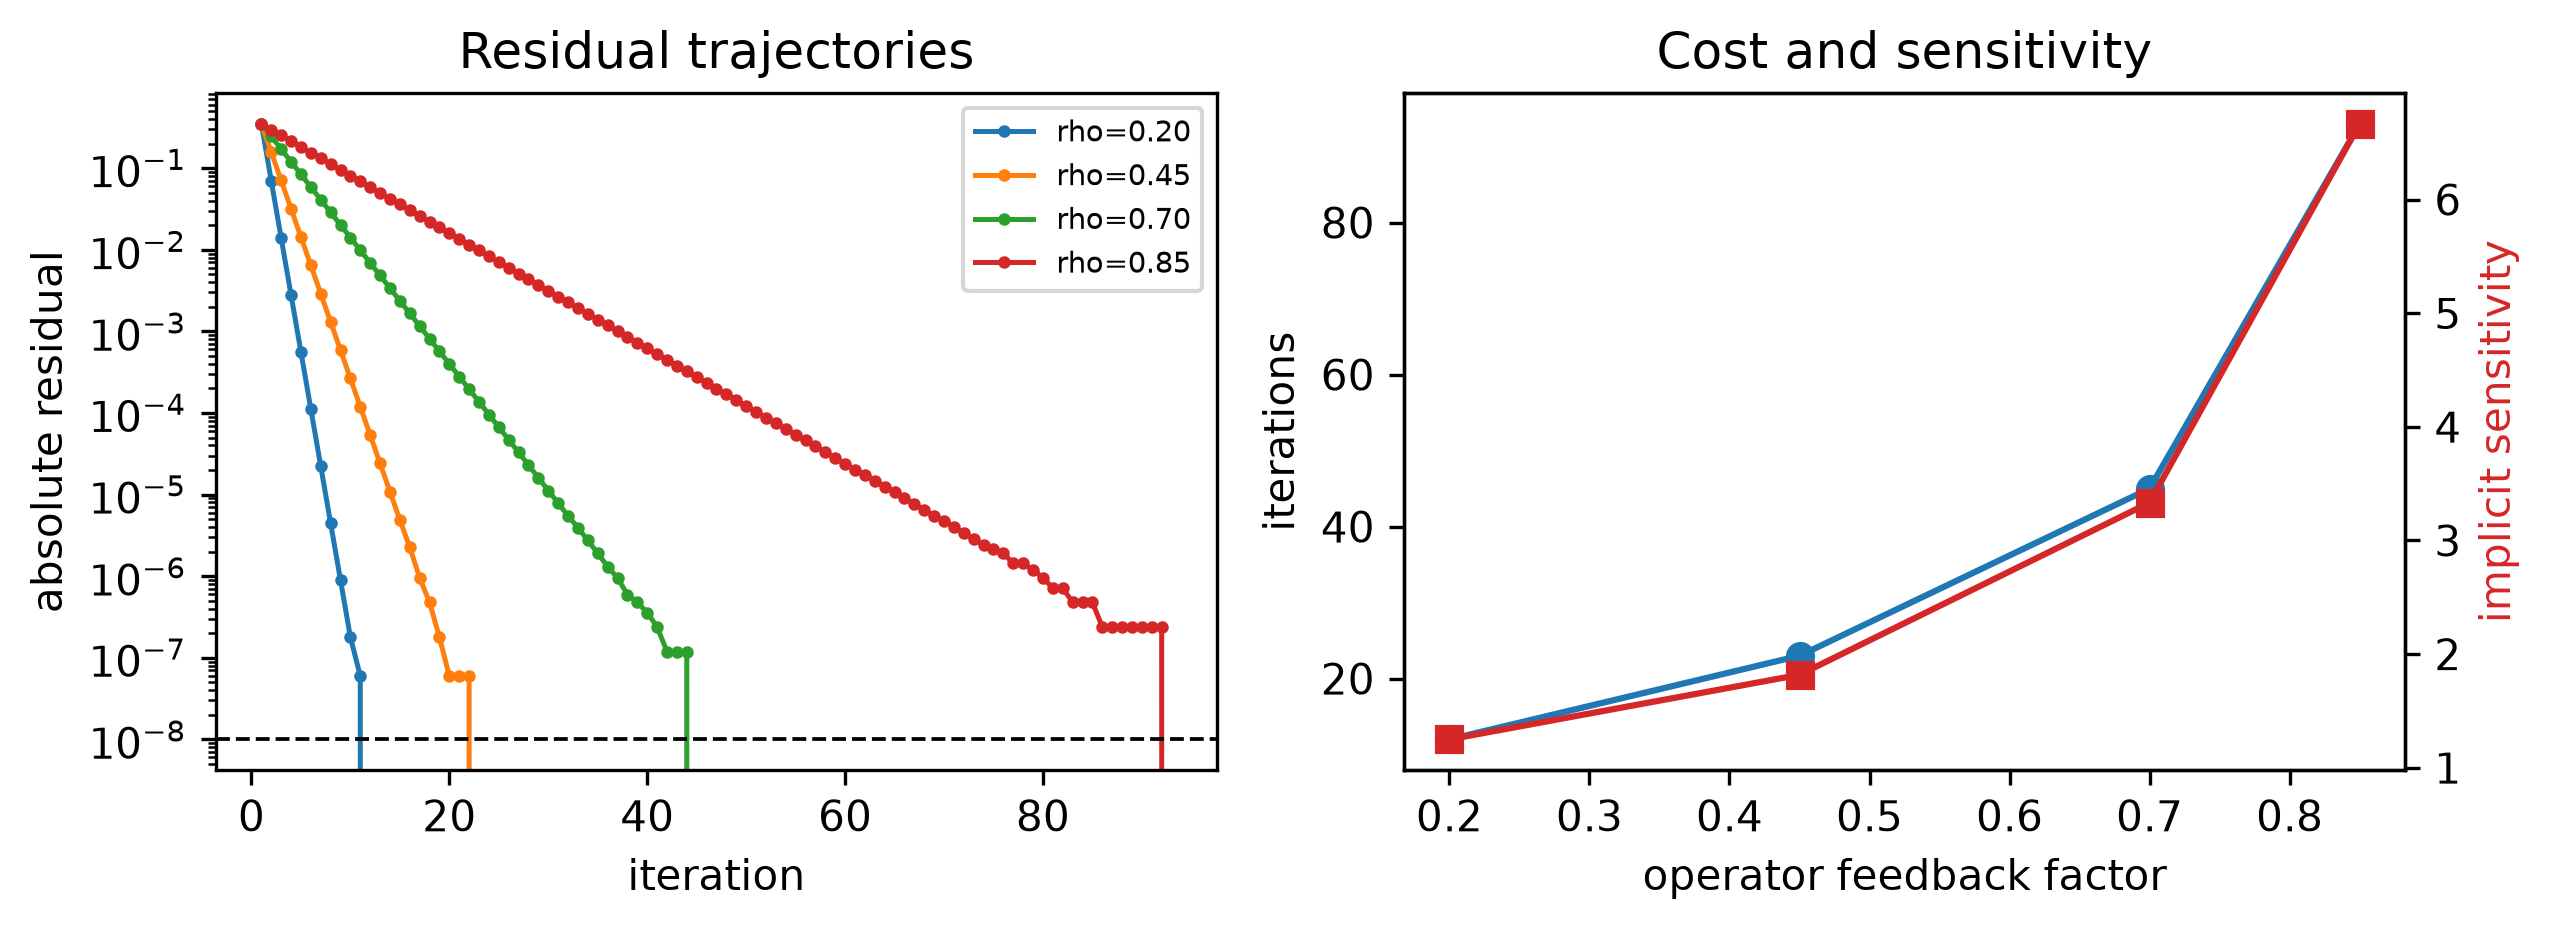

In [11]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('operator feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the operator feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | fixed-point residual and task error against a deterministic target |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | shape, device, dtype, finiteness, and differentiability |
| Scale sweep | Change one of state width, batch size, and data volume at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How does each named branch affect the transition? | [SILVA Operators](https://jseluis.github.io/silva-networks/learn/silva-operators/) |
| Which larger mappings can occupy one point? | [Point Architecture Catalog](https://jseluis.github.io/silva-networks/learn/point-architecture-catalog/) |
| Where are all operators combined in one example? | [Full Cortex Operators](https://jseluis.github.io/silva-networks/examples/full-cortex-operators/) |
